# Imports, plotting setup, and global display-name strategy

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("/content/prime-dataset.csv")

## =========================================================
# Global chronological split configuration
# =========================================================

SPLIT_CONFIG = {
    "train_start": pd.Timestamp("2017-04-01"),
    "train_end":   pd.Timestamp("2021-02-01"),

    "val_start":   pd.Timestamp("2021-03-01"),
    "val_end":     pd.Timestamp("2021-08-01"),

    "purge_start": pd.Timestamp("2021-09-01"),
    "purge_end":   pd.Timestamp("2022-08-01"),

    "test_start":  pd.Timestamp("2022-09-01"),
    "test_end":    pd.Timestamp("2023-12-01"),
}

def assign_split_by_date(df, date_col="Date", config=SPLIT_CONFIG):
    out = df.copy()
    out["split"] = np.nan

    out.loc[out[date_col].between(config["train_start"], config["train_end"]), "split"] = "train"
    out.loc[out[date_col].between(config["val_start"], config["val_end"]), "split"] = "val"
    out.loc[out[date_col].between(config["purge_start"], config["purge_end"]), "split"] = "purge"
    out.loc[out[date_col].between(config["test_start"], config["test_end"]), "split"] = "test"

    if out["split"].isna().any():
        bad_dates = sorted(out.loc[out["split"].isna(), date_col].drop_duplicates().tolist())
        raise ValueError(f"Some dates were not assigned to a split: {bad_dates}")

    return out

def show_split_summary(df, date_col="Date", split_col="split"):
    return (
        df.groupby(split_col)
          .agg(
              rows=("District", "size"),
              months=(date_col, "nunique"),
              start_date=(date_col, "min"),
              end_date=(date_col, "max"),
              districts=("District", "nunique"),
          )
          .reset_index()
          .sort_values("start_date")
    )

# manual overrides: these take priority whenever present
column_renaming = {
    'denv4': 'DENV-4',
    'Year': 'Year',
    'AvgTemp_lag_3': 'Avg. Temp (Lag 3)',
    'Month': 'Month',
    'PopulationDensity': 'Pop. Density',
    'MonthlyPrevailingWindDir_ENE': 'Wind Dir. (ENE)',
    'Rainfall_lag_2': 'Rainfall (Lag 2)',
    'MonthlyAvgSunshineHours _lag_1': 'Sunshine Hrs (Lag 1)',
    'denv1': 'DENV-1',
    'Humidity': 'Humidity',
    'Log_NoOfDenguePatients': 'Log(Dengue Cases)',
    "Month_cos": "Month (Cos)",
    "Month_sin": "Month (Sin)",
}

# because raw files often contain both clean and messy versions
column_renaming['MonthlyAvgSunshineHours_lag_1'] = 'Sunshine Hrs (Lag 1)'


def pretty_column_name(col: str) -> str:
    """
    Global display formatter for EVERY column shown in notebook outputs.
    Manual mapping first, then automatic cleanup/formatting.
    """
    if col in column_renaming:
        return column_renaming[col]

    c = str(col).strip()

    # handle lag suffix nicely
    lag_match = re.match(r"^(.*)_lag_(\d+)$", c)
    if lag_match:
        base, lag_num = lag_match.groups()
        return f"{pretty_column_name(base)} (Lag {lag_num})"

    # common exact replacements
    exact_map = {
        "NoOfDenguePatients": "Dengue Cases",
        "Log_NoOfDenguePatients": "Log(Dengue Cases)",
        "Month-year": "Month-Year",
        "PopulationDensity": "Pop. Density",
        "MonthlyAvgSunshineHours": "Sunshine Hrs",
        "MonthlyPrevailingWindDir": "Wind Direction",
        "MonthlyPrevailingWindSpeed": "Wind Speed",
        "MonthlyAvgSeaLevelPressure": "Sea Level Pressure",
        "MonthlyAvgVisibility": "Visibility",
        "AvgTemp": "Avg. Temp",
        "MinTemp": "Min. Temp",
        "MaxTemp": "Max. Temp",
        "Rainfall": "Rainfall",
        "Humidity": "Humidity",
        "dominant": "Dominant Serotype",
        "Date": "Date",
        "Month": "Month",
        "Year": "Year",
        "Month_sin": "Month (Sin)",
        "Month_cos": "Month (Cos)",
        "District": "District"
    }
    if c in exact_map:
        return exact_map[c]

    # dengue serotype columns like denv1, denv2, ...
    if re.fullmatch(r"denv\d+", c.lower()):
        num = re.findall(r"\d+", c)[0]
        return f"DENV-{num}"

    # one-hot wind direction columns
    if c.startswith("MonthlyPrevailingWindDir_"):
        suffix = c.replace("MonthlyPrevailingWindDir_", "").strip()
        return f"Wind Dir. ({suffix})"

    # generic cleanup
    c = c.replace("_", " ")
    c = re.sub(r"\s+", " ", c).strip()

    # split camel case into words
    c = re.sub(r"([a-z])([A-Z])", r"\1 \2", c)

    # some abbreviations
    c = c.replace("Avg ", "Avg. ")
    c = c.replace("Min ", "Min. ")
    c = c.replace("Max ", "Max. ")
    c = c.replace("Pop Density", "Pop. Density")

    return c


def rename_for_display(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy renamed only for display/plotting."""
    return df.rename(columns=pretty_column_name)


def display_names(cols):
    """Convert a list/index of raw column names into formatted labels."""
    return [pretty_column_name(c) for c in cols]

# Load prime dataset, fix chronology, create target + sin date encoding

In [2]:
df_raw = pd.read_csv(DATA_PATH)

# clean column names first
df_raw.columns = df_raw.columns.str.strip()
# clean categorical string values
for col in ["District", "dominant", "MonthlyPrevailingWindDir"]:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).str.strip().str.upper()
df_raw["dominant"] = df_raw["dominant"].astype(str).str.strip().str.lower()

# strict date parsing from Month-year
df_raw["Date"] = pd.to_datetime(df_raw["Month-year"], format="%y-%b", errors="raise")

# strict chronology
df_raw = df_raw.sort_values(["District", "Date"]).reset_index(drop=True)

# extract month/year from parsed date
df_raw["Month"] = df_raw["Date"].dt.month
df_raw["Year"] = df_raw["Date"].dt.year

# sin-cos-based cyclical month encoding
df_raw["Month_sin"] = np.sin(2 * np.pi * df_raw["Month"] / 12)
df_raw["Month_cos"] = np.cos(2 * np.pi * df_raw["Month"] / 12)

# target
df_raw["NoOfDenguePatients"] = pd.to_numeric(df_raw["NoOfDenguePatients"], errors="coerce")
df_raw["Log_NoOfDenguePatients"] = np.log1p(df_raw["NoOfDenguePatients"])

print(df_raw.shape)

display(
    rename_for_display(
        df_raw[
            [
                "District", "Month-year", "Date", "Month", "Year",
                "Month_sin", "NoOfDenguePatients", "Log_NoOfDenguePatients"
            ]
        ].head(10)
    )
)

print("\nDate range:", df_raw["Date"].min(), "to", df_raw["Date"].max())
print("Districts:", sorted(df_raw["District"].dropna().unique()))

(924, 25)


,District,Month-Year,Date,Month,Year,Month (Sin),Dengue Cases,Log(Dengue Cases)
0,BARISHAL,17-Jan,2017-01-01,1,2017,5.000000e-01,1,0.693147
1,BARISHAL,17-Feb,2017-02-01,2,2017,8.660254e-01,0,0.000000
2,BARISHAL,17-Mar,2017-03-01,3,2017,1.000000e+00,1,0.693147
3,BARISHAL,17-Apr,2017-04-01,4,2017,8.660254e-01,2,1.098612
4,BARISHAL,17-May,2017-05-01,5,2017,5.000000e-01,0,0.000000
5,BARISHAL,17-Jun,2017-06-01,6,2017,1.224647e-16,0,0.000000
6,BARISHAL,17-Jul,2017-07-01,7,2017,-5.000000e-01,2,1.098612
7,BARISHAL,17-Aug,2017-08-01,8,2017,-8.660254e-01,0,0.000000
8,BARISHAL,17-Sep,2017-09-01,9,2017,-1.000000e+00,0,0.000000
9,BARISHAL,17-Oct,2017-10-01,10,2017,-8.660254e-01,1,0.693147



Date range: 2017-01-01 00:00:00 to 2023-12-01 00:00:00
Districts: ['BARISHAL', 'BHOLA', 'CHATTOGRAM', 'COXS BAZAR', 'DHAKA', 'FARIDPUR', 'JESSORE', 'KHULNA', 'MYMENSINGH', 'RAJSHAHI', 'SYLHET']


# Sanity checks before feature engineering

In [3]:
missing_summary = df_raw.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
display(missing_summary if len(missing_summary) > 0 else pd.Series(dtype="int64"))

print("\nData types:")
display(df_raw.dtypes)

print("\nRows per district:")
display(df_raw["District"].value_counts().sort_index())

print("\nDuplicate District-Date rows:", df_raw.duplicated(subset=["District", "Date"]).sum())

Missing values by column:


,0



Data types:


,0
Month-year,object
District,object
PopulationDensity,int64
denv1,int64
denv2,int64
denv3,int64
denv4,int64
dominant,object
Rainfall,int64
MinTemp,float64



Rows per district:


,count
District,
BARISHAL,84
BHOLA,84
CHATTOGRAM,84
COXS BAZAR,84
DHAKA,84
FARIDPUR,84
JESSORE,84
KHULNA,84
MYMENSINGH,84



Duplicate District-Date rows: 0


# Mandatory consolidated colored boxplot by district

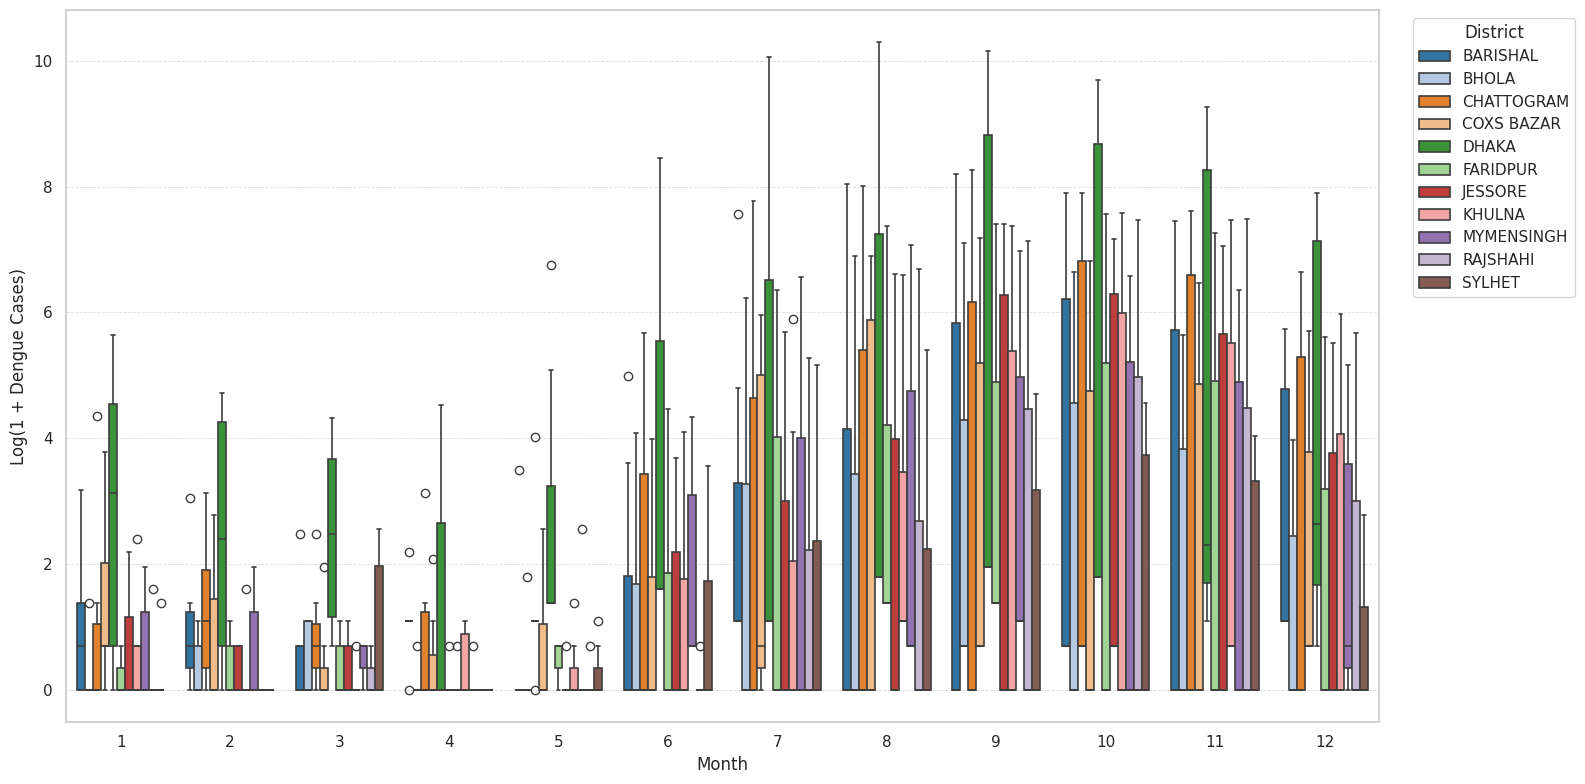

In [4]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df_raw,
    x="Month",
    y="Log_NoOfDenguePatients",
    hue="District",
    palette="tab20",
    linewidth=1.2
)

#plt.title("Monthly Distribution of Dengue Cases by District (log1p transformed)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Log(1 + Dengue Cases)")
plt.legend(title="District", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()

# Save as PDF with 200 DPI
plt.savefig("monthly_distribution_boxplot.pdf", format='pdf', dpi=200, bbox_inches="tight")
plt.show()

# Chronology check plot + leakage-free lag creation (NO imputation)

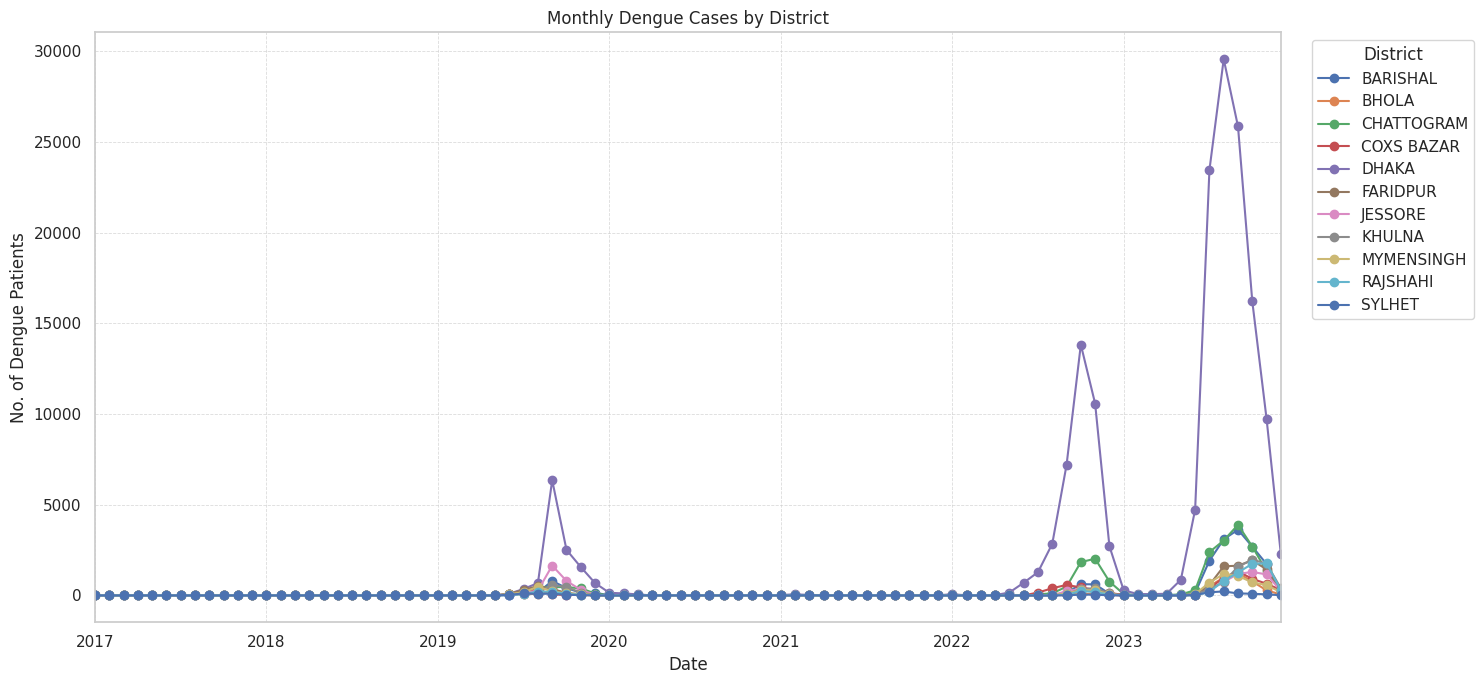

Created lag columns: 48
Rows with lag NaNs (expected at start of each district): 33


,District,Date,Month,Year,Month_sin,AvgTemp,AvgTemp_lag_1,AvgTemp_lag_2,AvgTemp_lag_3,Rainfall,...,Rainfall_lag_3,MonthlyAvgSunshineHours,MonthlyAvgSunshineHours_lag_1,dominant,dominant_lag_1,MonthlyPrevailingWindDir,MonthlyPrevailingWindDir_lag_1,NoOfDenguePatients,NoOfDenguePatients_lag_1,Log_NoOfDenguePatients
0,BARISHAL,2017-01-01,1,2017,5.000000e-01,18.1,NaN,NaN,NaN,0,...,NaN,7.6,NaN,sero_2,NaN,N,NaN,1,NaN,0.693147
1,BARISHAL,2017-02-01,2,2017,8.660254e-01,22.0,18.1,NaN,NaN,0,...,NaN,7.7,7.6,sero_2,sero_2,S,N,0,1.0,0.000000
2,BARISHAL,2017-03-01,3,2017,1.000000e+00,25.0,22.0,18.1,NaN,59,...,NaN,6.3,7.7,sero_2,sero_2,S,S,1,0.0,0.693147
3,BARISHAL,2017-04-01,4,2017,8.660254e-01,28.2,25.0,22.0,18.1,364,...,0.0,6.1,6.3,sero_2,sero_2,S,S,2,1.0,1.098612
4,BARISHAL,2017-05-01,5,2017,5.000000e-01,30.0,28.2,25.0,22.0,118,...,0.0,7.6,6.1,sero_2,sero_2,S,S,0,2.0,0.000000
5,BARISHAL,2017-06-01,6,2017,1.224647e-16,29.1,30.0,28.2,25.0,505,...,59.0,4.4,7.6,sero_2,sero_2,S,S,0,0.0,0.000000
6,BARISHAL,2017-07-01,7,2017,-5.000000e-01,28.3,29.1,30.0,28.2,550,...,364.0,2.4,4.4,sero_2,sero_2,S,S,2,0.0,1.098612
7,BARISHAL,2017-08-01,8,2017,-8.660254e-01,28.9,28.3,29.1,30.0,342,...,118.0,3.9,2.4,sero_2,sero_2,S,S,0,2.0,0.000000
8,BARISHAL,2017-09-01,9,2017,-1.000000e+00,28.5,28.9,28.3,29.1,228,...,505.0,3.5,3.9,sero_2,sero_2,S,S,0,0.0,0.000000
9,BARISHAL,2017-10-01,10,2017,-8.660254e-01,27.2,28.5,28.9,28.3,387,...,550.0,5.4,3.5,sero_2,sero_2,SE,S,1,0.0,0.693147


In [5]:
# chronology check plot
monthly_district = (
    df_raw.groupby(["Date", "District"], as_index=False)["NoOfDenguePatients"]
    .sum()
)

pivot_cases = monthly_district.pivot(index="Date", columns="District", values="NoOfDenguePatients")

pivot_cases.plot(figsize=(15, 7), marker="o")
plt.title("Monthly Dengue Cases by District")
plt.xlabel("Date")
plt.ylabel("No. of Dengue Patients")
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(title="District", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -------- leakage-free lag creation --------
df = df_raw.copy()

numeric_lag_cols = [
    "denv1", "denv2", "denv3", "denv4",
    "Rainfall", "MinTemp", "AvgTemp", "MaxTemp", "Humidity",
    "MonthlyAvgVisibility", "MonthlyAvgSeaLevelPressure",
    "MonthlyAvgSunshineHours", "MonthlyPrevailingWindSpeed",
    "NoOfDenguePatients"
]

categorical_lag_cols = [
    "dominant",
    "MonthlyPrevailingWindDir"
]

for col in numeric_lag_cols:
    for lag in [1, 2, 3]:
        df[f"{col}_lag_{lag}"] = df.groupby("District")[col].shift(lag)

for col in categorical_lag_cols:
    for lag in [1, 2, 3]:
        df[f"{col}_lag_{lag}"] = df.groupby("District")[col].shift(lag)

# no imputation here — keep lag-created NaNs
lag_cols = [c for c in df.columns if "_lag_" in c]

print("Created lag columns:", len(lag_cols))
print("Rows with lag NaNs (expected at start of each district):", df[lag_cols].isna().any(axis=1).sum())

display(df[[
    "District", "Date", "Month", "Year", "Month_sin",
    "AvgTemp", "AvgTemp_lag_1", "AvgTemp_lag_2", "AvgTemp_lag_3",
    "Rainfall", "Rainfall_lag_1", "Rainfall_lag_2", "Rainfall_lag_3",
    "MonthlyAvgSunshineHours", "MonthlyAvgSunshineHours_lag_1",
    "dominant", "dominant_lag_1",
    "MonthlyPrevailingWindDir", "MonthlyPrevailingWindDir_lag_1",
    "NoOfDenguePatients", "NoOfDenguePatients_lag_1",
    "Log_NoOfDenguePatients"
]].head(12))

**And whenever we plot anything with feature names, this pattern should be used**

Example for correlations


```
corr_df = some_df.copy()
corr_df = corr_df.rename(columns=pretty_column_name)
```


Example for selected-feature bar plot

```
plot_df = feature_importance_df.copy()
plot_df["Feature"] = plot_df["Feature"].map(pretty_column_name)
```
Example for heatmap labels
```
heatmap_df = model_df[selected_cols].copy()
heatmap_df = heatmap_df.rename(columns=pretty_column_name)
```


Important rule from now on

We will use:

- `raw names` for engineering and modeling

- `pretty_column_name()` for all displayed names everywhere

# Keep only leakage-free usable rows (no lag imputation)

In [6]:
# keep rows where all generated lag features are available
# this only removes the initial lag-burn-in rows within each district
required_for_model = lag_cols + [
    "NoOfDenguePatients",
    "Log_NoOfDenguePatients",
    "Month",
    "Year",
    "Month_sin",
    "Month_cos"
]

df_model = df.dropna(subset=required_for_model).copy().reset_index(drop=True)

print("Original rows:", len(df))
print("Usable rows after removing lag-burn-in rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))


# assign chronological splits AFTER lag-burn-in removal
df_model = assign_split_by_date(df_model)

print("\nSplit summary:")
display(show_split_summary(df_model))

train_df = df_model[df_model["split"] == "train"].copy().reset_index(drop=True)
val_df   = df_model[df_model["split"] == "val"].copy().reset_index(drop=True)
purge_df = df_model[df_model["split"] == "purge"].copy().reset_index(drop=True)
test_df  = df_model[df_model["split"] == "test"].copy().reset_index(drop=True)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Purge rows:", len(purge_df))
print("Test rows:", len(test_df))

Original rows: 924
Usable rows after removing lag-burn-in rows: 891
Dropped rows: 33

Split summary:


/tmp/ipykernel_10689/1682247009.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'train' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[out[date_col].between(config["train_start"], config["train_end"]), "split"] = "train"


,split,rows,months,start_date,end_date,districts
2,train,517,47,2017-04-01,2021-02-01,11
3,val,66,6,2021-03-01,2021-08-01,11
0,purge,132,12,2021-09-01,2022-08-01,11
1,test,176,16,2022-09-01,2023-12-01,11


Train rows: 517
Val rows: 66
Purge rows: 132
Test rows: 176


In [7]:
district_row_summary = (
    df.assign(_usable=~df[required_for_model].isna().any(axis=1))
      .groupby("District")["_usable"]
      .agg(total_rows="size", usable_rows="sum")
      .reset_index()
)
district_row_summary["dropped_rows"] = district_row_summary["total_rows"] - district_row_summary["usable_rows"]

display(rename_for_display(district_row_summary))

print("\nAny remaining missing values in required modeling columns?",
      df_model[required_for_model].isna().sum().sum())

,District,total rows,usable rows,dropped rows
0,BARISHAL,84,81,3
1,BHOLA,84,81,3
2,CHATTOGRAM,84,81,3
3,COXS BAZAR,84,81,3
4,DHAKA,84,81,3
5,FARIDPUR,84,81,3
6,JESSORE,84,81,3
7,KHULNA,84,81,3
8,MYMENSINGH,84,81,3
9,RAJSHAHI,84,81,3



Any remaining missing values in required modeling columns? 0


# One-hot encode categorical predictors and create global display labels for new dummy columns


In [8]:
"""# One-hot encode categorical predictors using TRAIN only, then align other splits"""

categorical_cols = [
    "dominant",
    "dominant_lag_1", "dominant_lag_2", "dominant_lag_3",
    "MonthlyPrevailingWindDir",
    "MonthlyPrevailingWindDir_lag_1",
    "MonthlyPrevailingWindDir_lag_2",
    "MonthlyPrevailingWindDir_lag_3"
]

categorical_cols = [c for c in categorical_cols if c in df_model.columns]

def encode_like_train(train_df, other_dfs, categorical_cols):
    train_enc = train_df.copy()

    for col in categorical_cols:
        if col in train_enc.columns:
            train_enc[col] = train_enc[col].astype(str).str.strip().str.upper()

    train_enc = pd.get_dummies(
        train_enc,
        columns=categorical_cols,
        drop_first=False,
        dtype=int
    )

    train_columns = train_enc.columns.tolist()
    encoded_others = []

    for df_part in other_dfs:
        part = df_part.copy()

        for col in categorical_cols:
            if col in part.columns:
                part[col] = part[col].astype(str).str.strip().str.upper()

        part = pd.get_dummies(
            part,
            columns=categorical_cols,
            drop_first=False,
            dtype=int
        )

        part = part.reindex(columns=train_columns, fill_value=0)
        encoded_others.append(part)

    return train_enc, encoded_others, train_columns

train_encoded, [val_encoded, purge_encoded, test_encoded], train_encoded_columns = encode_like_train(
    train_df, [val_df, purge_df, test_df], categorical_cols
)

# ---------- global display-name overrides for generated dummy columns ----------
def _format_serotype_value(v: str) -> str:
    v = str(v).strip()
    if v.lower().startswith("denv"):
        num = "".join(ch for ch in v if ch.isdigit())
        return f"DENV-{num}" if num else v.upper()
    return v

for col in train_encoded.columns:
    if col.startswith("dominant_") and "_lag_" not in col:
        sero = col.replace("dominant_", "", 1)
        column_renaming[col] = f"Dominant ({_format_serotype_value(sero)})"

    lag_match = re.match(r"^dominant_lag_(\d+)_(.+)$", col)
    if lag_match:
        lag_n, sero = lag_match.groups()
        column_renaming[col] = f"Dominant (Lag {lag_n}: {_format_serotype_value(sero)})"

    wind_match = re.match(r"^MonthlyPrevailingWindDir_(.+)$", col)
    if wind_match and "_lag_" not in col:
        direction = wind_match.group(1)
        column_renaming[col] = f"Wind Dir. ({direction})"

    wind_lag_match = re.match(r"^MonthlyPrevailingWindDir_lag_(\d+)_(.+)$", col)
    if wind_lag_match:
        lag_n, direction = wind_lag_match.groups()
        column_renaming[col] = f"Wind Dir. (Lag {lag_n}: {direction})"

print("Train encoded shape:", train_encoded.shape)
print("Val encoded shape:", val_encoded.shape)
print("Purge encoded shape:", purge_encoded.shape)
print("Test encoded shape:", test_encoded.shape)

encoded_new_cols = [c for c in train_encoded.columns if c not in train_df.columns]
print("New dummy columns created from TRAIN:", len(encoded_new_cols))

display(rename_for_display(
    train_encoded[["District", "Date", "Month", "Year", "Month_sin", "Month_cos"] + encoded_new_cols[:10]].head()
))

Train encoded shape: (517, 138)
Val encoded shape: (66, 138)
Purge encoded shape: (132, 138)
Test encoded shape: (176, 138)
New dummy columns created from TRAIN: 72


,District,Date,Month,Year,Month (Sin),Month (Cos),Dominant (SERO_2),Dominant (SERO_3),Dominant (Lag 1: SERO_2),Dominant (Lag 1: SERO_3),Dominant (Lag 2: SERO_2),Dominant (Lag 2: SERO_3),Dominant (Lag 3: SERO_2),Dominant (Lag 3: SERO_3),Wind Dir. (E),Wind Dir. (ENE)
0,BARISHAL,2017-04-01,4,2017,8.660254e-01,-0.500000,1,0,1,0,1,0,1,0,0,0
1,BARISHAL,2017-05-01,5,2017,5.000000e-01,-0.866025,1,0,1,0,1,0,1,0,0,0
2,BARISHAL,2017-06-01,6,2017,1.224647e-16,-1.000000,1,0,1,0,1,0,1,0,0,0
3,BARISHAL,2017-07-01,7,2017,-5.000000e-01,-0.866025,1,0,1,0,1,0,1,0,0,0
4,BARISHAL,2017-08-01,8,2017,-8.660254e-01,-0.500000,1,0,1,0,1,0,1,0,0,0


cell 8

In [9]:
# Cell 8: finalize post-preprocessing dataframe and keep chronology columns for later use

df_final = train_encoded.copy().sort_values(["District", "Date"]).reset_index(drop=True)
df_val_final = val_encoded.copy().sort_values(["District", "Date"]).reset_index(drop=True)
df_purge_final = purge_encoded.copy().sort_values(["District", "Date"]).reset_index(drop=True)
df_test_final = test_encoded.copy().sort_values(["District", "Date"]).reset_index(drop=True)

target_col = "Log_NoOfDenguePatients"

# keep these for reference / future modeling split, but not as predictors
reference_cols = ["District", "Date", "Month-year"]

# never use these as predictors
forbidden_predictors = [
    "NoOfDenguePatients",      # same-time raw target
    "Log_NoOfDenguePatients",  # target itself
    "Date",
    "Month-year"
]

print("Final preprocessed shape:", df_final.shape)
display(rename_for_display(df_final[["District", "Date", "Month", "Year", "Month_sin", target_col]].head()))

Final preprocessed shape: (517, 138)


,District,Date,Month,Year,Month (Sin),Log(Dengue Cases)
0,BARISHAL,2017-04-01,4,2017,8.660254e-01,1.098612
1,BARISHAL,2017-05-01,5,2017,5.000000e-01,0.000000
2,BARISHAL,2017-06-01,6,2017,1.224647e-16,0.000000
3,BARISHAL,2017-07-01,7,2017,-5.000000e-01,1.098612
4,BARISHAL,2017-08-01,8,2017,-8.660254e-01,0.000000


cell 9

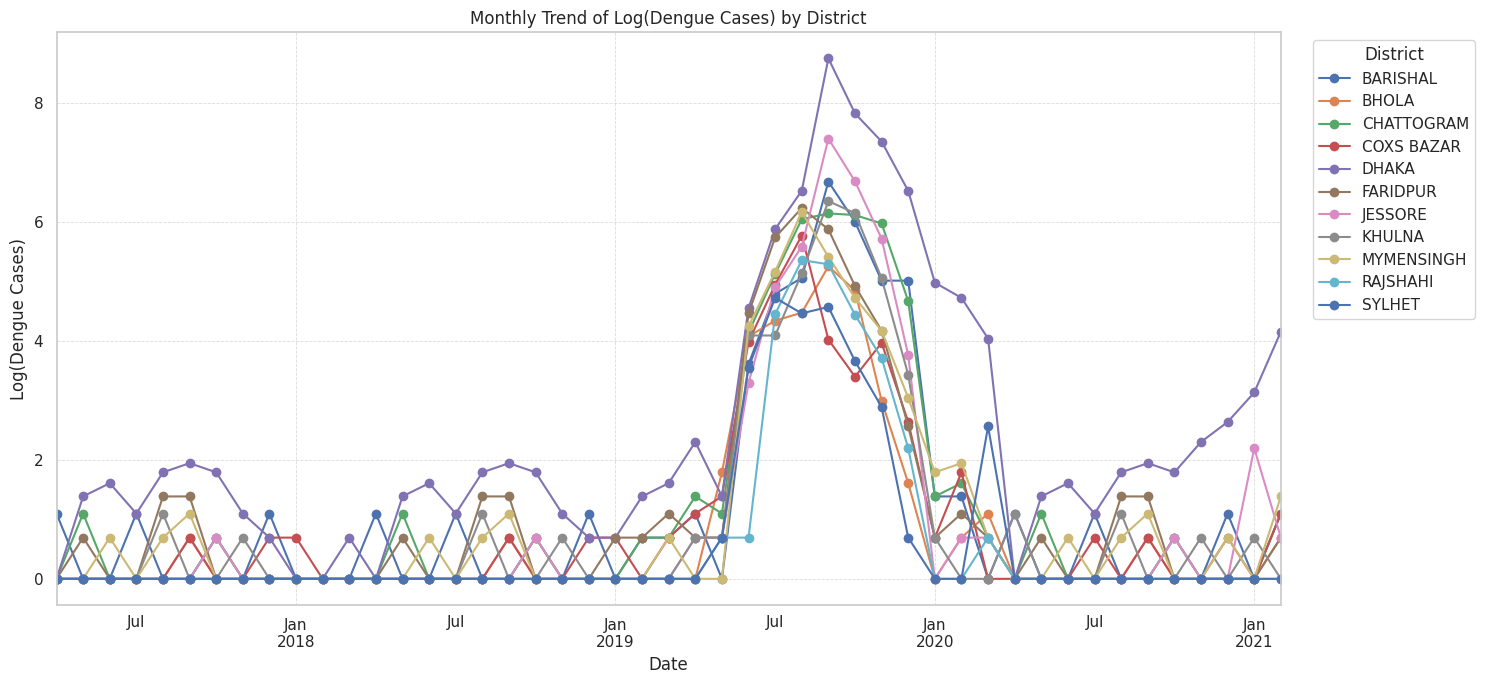

In [10]:
# Cell 9: keep the trend plot after preprocessing

district_monthly_cases = (
    df_final.groupby(["Date", "District"], as_index=False)[target_col]
    .mean()
)

pivot_log_cases = district_monthly_cases.pivot(index="Date", columns="District", values=target_col)

pivot_log_cases.plot(figsize=(15, 7), marker="o")
plt.title("Monthly Trend of Log(Dengue Cases) by District")
plt.xlabel("Date")
plt.ylabel("Log(Dengue Cases)")
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(title="District", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# Save as PDF with 200 DPI
plt.savefig("monthly_trend_log_cases.pdf", format='pdf', dpi=200, bbox_inches="tight")
plt.show()

# Correlation-based elimination with protected features

In [11]:
protected_features = {
    "denv4",
    "Year",
    "AvgTemp_lag_3",
    "Month_sin",
    "Month_cos",
    "PopulationDensity",
    "MonthlyPrevailingWindDir_ENE",
    "Rainfall_lag_2",
    "Rainfall_lag_3",
    "MonthlyAvgSunshineHours_lag_1",
    "denv1_lag_1",
    "Humidity_lag_1"
}

print("Protected features present in dataframe:")
print([c for c in protected_features if c in df_final.columns])

print("\nProtected features missing from dataframe:")
print([c for c in protected_features if c not in df_final.columns])

Protected features present in dataframe:
['MonthlyAvgSunshineHours_lag_1', 'denv4', 'Month_sin', 'Year', 'Month_cos', 'MonthlyPrevailingWindDir_ENE', 'denv1_lag_1', 'Rainfall_lag_2', 'Humidity_lag_1', 'AvgTemp_lag_3', 'PopulationDensity', 'Rainfall_lag_3']

Protected features missing from dataframe:
[]


In [12]:
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
candidate_cols = [c for c in numeric_cols if c not in forbidden_predictors]

X_num = df_final[candidate_cols].copy()
y = df_final[target_col].copy()

# abs correlation with target for tie-breaking
target_abs_corr = X_num.apply(lambda s: s.corr(y)).abs().fillna(0)

corr_threshold = 0.90
corr_matrix = X_num.corr().abs()

to_drop_corr = set()
protected_conflict_pairs = []
drop_reasons = []

cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]

        if corr_matrix.loc[c1, c2] <= corr_threshold:
            continue

        # if one is already marked for dropping, skip extra logic
        if c1 in to_drop_corr or c2 in to_drop_corr:
            continue

        c1_protected = c1 in protected_features
        c2_protected = c2 in protected_features

        # case 1: both protected -> keep both for now, log conflict
        if c1_protected and c2_protected:
            protected_conflict_pairs.append((c1, c2, corr_matrix.loc[c1, c2]))
            continue

        # case 2: one protected -> drop the non-protected one
        if c1_protected and not c2_protected:
            to_drop_corr.add(c2)
            drop_reasons.append((c2, c1, "Dropped because highly correlated with protected feature"))
            continue

        if c2_protected and not c1_protected:
            to_drop_corr.add(c1)
            drop_reasons.append((c1, c2, "Dropped because highly correlated with protected feature"))
            continue

        # case 3: neither protected -> drop weaker one based on target abs correlation
        if target_abs_corr[c1] < target_abs_corr[c2]:
            to_drop_corr.add(c1)
            drop_reasons.append((c1, c2, "Dropped due to weaker target correlation"))
        else:
            to_drop_corr.add(c2)
            drop_reasons.append((c2, c1, "Dropped due to weaker target correlation"))

corr_reduced_cols = [c for c in candidate_cols if c not in to_drop_corr]

print("Initial candidate numeric features:", len(candidate_cols))
print("Dropped by high inter-feature correlation:", len(to_drop_corr))
print("Remaining after correlation filter:", len(corr_reduced_cols))

print("\nProtected feature conflict pairs kept for later manual review:")
display(pd.DataFrame(
    protected_conflict_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
) if protected_conflict_pairs else pd.DataFrame({"Message": ["No protected-protected conflicts"]}))

print("\nDropped features and reasons:")
display(pd.DataFrame(
    drop_reasons,
    columns=["Dropped Feature", "Compared With", "Reason"]
) if drop_reasons else pd.DataFrame({"Message": ["No columns dropped at current threshold"]}))

Initial candidate numeric features: 132
Dropped by high inter-feature correlation: 120
Remaining after correlation filter: 12

Protected feature conflict pairs kept for later manual review:


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Feature 1,Feature 2,Correlation
0,PopulationDensity,denv4,NaN
1,denv4,Year,NaN
2,denv4,Month_sin,NaN
3,denv4,Month_cos,NaN
4,denv4,denv1_lag_1,NaN
5,denv4,Rainfall_lag_2,NaN
6,denv4,Rainfall_lag_3,NaN
7,denv4,AvgTemp_lag_3,NaN
8,denv4,Humidity_lag_1,NaN
9,denv4,MonthlyAvgSunshineHours_lag_1,NaN



Dropped features and reasons:


,Dropped Feature,Compared With,Reason
0,denv4_lag_1,PopulationDensity,Dropped because highly correlated with protect...
1,denv4_lag_2,PopulationDensity,Dropped because highly correlated with protect...
2,denv4_lag_3,PopulationDensity,Dropped because highly correlated with protect...
3,denv1,denv4,Dropped because highly correlated with protect...
4,denv3,denv2,Dropped due to weaker target correlation
...,...,...,...
115,MonthlyPrevailingWindDir_lag_3_SSW,denv4,Dropped because highly correlated with protect...
116,MonthlyPrevailingWindDir_lag_3_SW,denv4,Dropped because highly correlated with protect...
117,MonthlyPrevailingWindDir_lag_3_W,denv4,Dropped because highly correlated with protect...
118,MonthlyPrevailingWindDir_lag_3_WNW,denv4,Dropped because highly correlated with protect...


# VIF reduction with protected features

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_final[corr_reduced_cols].copy().astype(float)

# remove zero-variance columns first
zero_var_cols = [c for c in X_vif.columns if X_vif[c].nunique() <= 1]
if zero_var_cols:
    X_vif = X_vif.drop(columns=zero_var_cols)

vif_threshold = 10.0
dropped_by_vif = []
vif_stop_reason = None

while True:
    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    # all features above threshold
    high_vif_df = vif_df[vif_df["VIF"] > vif_threshold].copy()

    # among them, which are NOT protected
    droppable_df = high_vif_df[~high_vif_df["Feature"].isin(protected_features)].copy()

    # stop if no feature exceeds threshold
    if high_vif_df.empty:
        vif_stop_reason = "Stopped because all VIF values are within threshold."
        break

    # stop if only protected high-VIF features remain
    if droppable_df.empty:
        vif_stop_reason = "Stopped because only protected features remain above the VIF threshold."
        break

    # drop the worst non-protected feature
    drop_col = droppable_df.iloc[0]["Feature"]
    dropped_by_vif.append(drop_col)
    X_vif = X_vif.drop(columns=[drop_col])

vif_selected_cols = X_vif.columns.tolist()

print("Dropped by VIF:", len(dropped_by_vif))
print("Remaining after VIF filtering:", len(vif_selected_cols))
print("Stop reason:", vif_stop_reason)

display(pd.DataFrame({
    "Dropped Feature": dropped_by_vif,
    "Display Name": [pretty_column_name(c) for c in dropped_by_vif]
}) if dropped_by_vif else pd.DataFrame({"Message": ["No columns dropped by VIF"]}))

final_vif_df = pd.DataFrame({
    "Feature": vif_selected_cols,
    "Display Name": [pretty_column_name(c) for c in vif_selected_cols],
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

display(final_vif_df)

Dropped by VIF: 0
Remaining after VIF filtering: 11
Stop reason: Stopped because only protected features remain above the VIF threshold.


,Message
0,No columns dropped by VIF


,Feature,Display Name,VIF
0,Year,Year,805.014090
1,Humidity_lag_1,Humidity (Lag 1),647.434463
2,AvgTemp_lag_3,Avg. Temp (Lag 3),264.734267
3,MonthlyAvgSunshineHours_lag_1,Sunshine Hrs (Lag 1),26.692824
4,Month_sin,Month (Sin),7.807593
5,Rainfall_lag_3,Rainfall (Lag 3),4.520974
6,Rainfall_lag_2,Rainfall (Lag 2),4.291947
7,Month_cos,Month (Cos),2.452431
8,PopulationDensity,Pop. Density,2.376816
9,denv1_lag_1,DENV-1 (Lag 1),1.987136


# SelectKBest = screening only, not final selection

In [14]:
from sklearn.feature_selection import SelectKBest, f_regression

X_kbest = df_final[vif_selected_cols].copy()
y_kbest = df_final[target_col].copy()

k = min(35, X_kbest.shape[1])   # paper version uses top 35 as screening stage
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_kbest, y_kbest)

kbest_cols = X_kbest.columns[selector.get_support()].tolist()

kbest_scores_df = pd.DataFrame({
    "Raw Feature": X_kbest.columns,
    "Feature": [pretty_column_name(c) for c in X_kbest.columns],
    "F_score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("F_score", ascending=False).reset_index(drop=True)

display(kbest_scores_df)

print("Features entering SelectKBest:", X_kbest.shape[1])
print("Features retained by SelectKBest:", len(kbest_cols))
print("\nTop KBest features:")
print(kbest_cols)

# Save results to CSV
kbest_scores_df.to_csv("kbest_scores.csv", index=False)

,Raw Feature,Feature,F_score,p_value
0,Month_sin,Month (Sin),46.870466,2.164944e-11
1,AvgTemp_lag_3,Avg. Temp (Lag 3),43.534651,1.036244e-10
2,PopulationDensity,Pop. Density,33.374109,1.317017e-08
3,Year,Year,14.967440,1.234145e-04
4,MonthlyAvgSunshineHours_lag_1,Sunshine Hrs (Lag 1),8.017026,4.815236e-03
5,MonthlyPrevailingWindDir_ENE,Wind Dir. (ENE),7.995763,4.871220e-03
6,denv1_lag_1,DENV-1 (Lag 1),6.001564,1.462509e-02
7,Humidity_lag_1,Humidity (Lag 1),5.893526,1.553835e-02
8,Rainfall_lag_2,Rainfall (Lag 2),4.213721,4.060301e-02
9,Rainfall_lag_3,Rainfall (Lag 3),1.044737,3.072022e-01


Features entering SelectKBest: 11
Features retained by SelectKBest: 11

Top KBest features:
['PopulationDensity', 'Year', 'Month_sin', 'Month_cos', 'denv1_lag_1', 'Rainfall_lag_2', 'Rainfall_lag_3', 'AvgTemp_lag_3', 'Humidity_lag_1', 'MonthlyAvgSunshineHours_lag_1', 'MonthlyPrevailingWindDir_ENE']


# Final manual feature selection for the paper version

In [15]:
# KBest is screening only.
# Final 10 must be chosen manually based on:
# 1. target relevance
# 2. low multicollinearity
# 3. manuscript/domain relevance

# final_feature_list = [
#     "denv4",
#     "denv4_lag_3",
#     "Year",
#     "AvgTemp_lag_3",
#     "Month",
#     "PopulationDensity",
#     "MonthlyPrevailingWindDir_ENE",
#     "Rainfall_lag_2",
#     "MonthlyAvgSunshineHours_lag_1",
#     "denv1",
#     "Humidity",
#     "MonthlyPrevailingWindDir_lag_3_N"
# ]
final_feature_list = [
    "denv4",
    "Year",
    "AvgTemp_lag_3",
    "Month_sin",
    "Month_cos",
    "PopulationDensity",
    "MonthlyPrevailingWindDir_ENE",
    "Rainfall_lag_2",
    "MonthlyAvgSunshineHours_lag_1",
    "denv1_lag_1",
    "Humidity_lag_1"
]

missing_final_features = [c for c in final_feature_list if c not in df_final.columns]
if missing_final_features:
    print("These final features are missing from df_final:")
    print(missing_final_features)
else:
    print("All final features are available.")

print("\nFinal manual feature list:")
for i, col in enumerate(final_feature_list, start=1):
    print(f"{i}. {col} --> {pretty_column_name(col)}")

final_feature_df = df_final[reference_cols + final_feature_list + [target_col]].copy()

display(rename_for_display(final_feature_df.head()))

All final features are available.

Final manual feature list:
1. denv4 --> DENV-4
2. Year --> Year
3. AvgTemp_lag_3 --> Avg. Temp (Lag 3)
4. Month_sin --> Month (Sin)
5. Month_cos --> Month (Cos)
6. PopulationDensity --> Pop. Density
7. MonthlyPrevailingWindDir_ENE --> Wind Dir. (ENE)
8. Rainfall_lag_2 --> Rainfall (Lag 2)
9. MonthlyAvgSunshineHours_lag_1 --> Sunshine Hrs (Lag 1)
10. denv1_lag_1 --> DENV-1 (Lag 1)
11. Humidity_lag_1 --> Humidity (Lag 1)


,District,Date,Month-Year,DENV-4,Year,Avg. Temp (Lag 3),Month (Sin),Month (Cos),Pop. Density,Wind Dir. (ENE),Rainfall (Lag 2),Sunshine Hrs (Lag 1),DENV-1 (Lag 1),Humidity (Lag 1),Log(Dengue Cases)
0,BARISHAL,2017-04-01,17-Apr,0,2017,18.1,8.660254e-01,-0.500000,923,0,0.0,6.3,4.0,81.0,1.098612
1,BARISHAL,2017-05-01,17-May,0,2017,22.0,5.000000e-01,-0.866025,923,0,59.0,6.1,4.0,81.0,0.000000
2,BARISHAL,2017-06-01,17-Jun,0,2017,25.0,1.224647e-16,-1.000000,923,0,364.0,7.6,4.0,79.0,0.000000
3,BARISHAL,2017-07-01,17-Jul,0,2017,28.2,-5.000000e-01,-0.866025,923,0,118.0,4.4,4.0,87.0,1.098612
4,BARISHAL,2017-08-01,17-Aug,0,2017,30.0,-8.660254e-01,-0.500000,923,0,505.0,2.4,4.0,93.0,0.000000


# Final stylized correlation heatmap and dataset export

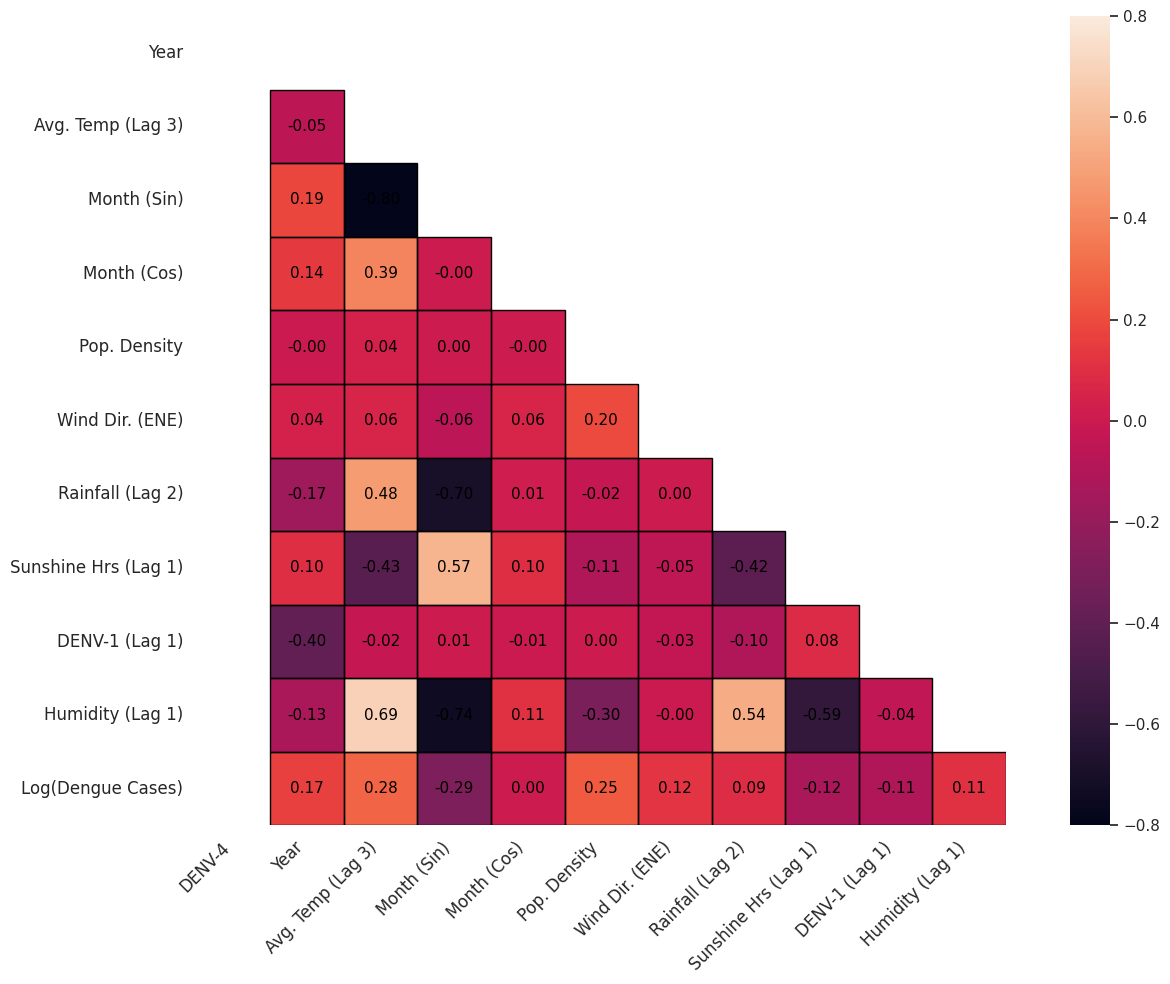

Saved modeling dataset to: prime_dataset_model_input_with_purge.csv
split
train    517
test     176
purge    132
val       66
Name: count, dtype: int64


In [16]:
import numpy as np
from matplotlib.patches import Rectangle

# 1. Prepare Data
heatmap_cols = final_feature_list + [target_col]
df_corr = df_final[heatmap_cols].copy()

# 2. Rename Variables using the global formatter
df_corr = df_corr.rename(columns=pretty_column_name)

# 3. Calculate Correlation
corr_matrix = df_corr.corr()

# 4. Set Diagonal and Upper Triangle to NaN
mask_indices = np.triu_indices_from(corr_matrix, k=0)
corr_matrix.values[mask_indices] = np.nan

# 5. Trim the Matrix
corr_trimmed = corr_matrix.iloc[1:, :-1]

# 6. Plotting
plt.figure(figsize=(14, 10))
ax = plt.gca()
ax.set_facecolor("white")
ax.grid(False)  # Explicitly turn off the grid

sns.heatmap(
    corr_trimmed,
    annot=True,
    fmt=".2f",
    #cmap="YlGnBu",
    square=True,
    cbar=True,
    linewidths=0,
    vmin=-.8, vmax=.8,
    annot_kws={"size": 11, "color": "black"}
)

# 7. Manually Draw Borders
rows, cols = corr_trimmed.shape
for i in range(rows):
    for j in range(cols):
        if not np.isnan(corr_trimmed.iloc[i, j]):
            rect = Rectangle((j, i), 1, 1, fill=False, edgecolor="black", lw=1)
            ax.add_patch(rect)

# 8. Formatting
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
#plt.title("Final Feature Correlation Matrix", fontsize=15, pad=20)
plt.tight_layout()

# Save as PDF with 200 DPI
plt.savefig("correlation_matrix_clean_triangle.pdf", format='pdf', dpi=200, bbox_inches="tight")
plt.show()

train_selected_dataset = df_final[reference_cols + ["split"] + final_feature_list + [target_col]].copy()
val_selected_dataset   = df_val_final[reference_cols + ["split"] + final_feature_list + [target_col]].copy()
purge_selected_dataset = df_purge_final[reference_cols + ["split"] + final_feature_list + [target_col]].copy()
test_selected_dataset  = df_test_final[reference_cols + ["split"] + final_feature_list + [target_col]].copy()

all_selected_dataset = pd.concat(
    [
        train_selected_dataset,
        val_selected_dataset,
        purge_selected_dataset,
        test_selected_dataset,
    ],
    axis=0,
    ignore_index=True
)

output_path = "prime_dataset_model_input_with_purge.csv"
all_selected_dataset.to_csv(output_path, index=False)

print(f"Saved modeling dataset to: {output_path}")
print(all_selected_dataset["split"].value_counts())

In [17]:
output_path = "prime_dataset_final_selected_features_with_splits.csv"
all_selected_dataset.to_csv(output_path, index=False)

print(f"Saved final dataset to: {output_path}")
print(f"Final dataset shape: {all_selected_dataset.shape}")
print(all_selected_dataset['split'].value_counts())

Saved final dataset to: prime_dataset_final_selected_features_with_splits.csv
Final dataset shape: (891, 16)
split
train    517
test     176
purge    132
val       66
Name: count, dtype: int64
